In [44]:
# =====================================================
# XGBoost vs Random Forest vs SVM
# Publication-Ready Wildfire Classification Pipeline
# =====================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# =====================================================
# LOAD DATASET
# =====================================================

import pandas as pd

DATASET_PATH = "/content/Algerian_Forest_Data1.csv"

df = pd.read_csv(DATASET_PATH)

df.columns = df.columns.str.strip()

df["Classes"] = (
    df["Classes"]
    .astype(str)
    .str.strip()
)

df["Classes"] = df["Classes"].map({
    "fire": 1,
    "not fire": 0
})

df = df.dropna()


In [9]:
# =====================================================
# CATEGORICAL ENCODING
# =====================================================

categorical_cols = []

for col in ["Season", "VegetationType"]:
    if col in df.columns:
        categorical_cols.append(col)

if len(categorical_cols) > 0:

    df = pd.get_dummies(
        df,
        columns=categorical_cols,
        drop_first=True
    )

In [11]:
# =====================================================
# FEATURES / TARGET
# =====================================================

y = df["Classes"]
X = df.drop(columns=["Classes"])

features = X.columns.tolist()

print("\\nDataset Shape:", df.shape)
print("\\nClass Distribution:")
print(y.value_counts())

print("\\nTotal Features:", len(features))

\nDataset Shape: (2904, 20)
\nClass Distribution:
Classes
1    1452
0    1452
Name: count, dtype: int64
\nTotal Features: 19


In [14]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# =====================================================
# SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [23]:
# =====================================================
# XGBOOST
# =====================================================

print("\\nTraining XGBoost...")

xgb_pipeline = Pipeline([
    ("model",
     xgb.XGBClassifier(
         objective="binary:logistic",
         eval_metric="logloss",
         random_state=42
     ))
])

\nTraining XGBoost...


In [25]:
xgb_params = {

    "model__n_estimators": [100, 200, 400],

    "model__max_depth": [3, 5, 7, 9],

    "model__learning_rate": [0.01, 0.05, 0.1],

    "model__subsample": [0.8, 1.0],

    "model__colsample_bytree": [0.8, 1.0]
}


In [29]:
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [31]:
xgb_grid.fit(X_train, y_train)

xgb_model = xgb_grid.best_estimator_

print("\\nBest XGB Params")
print(xgb_grid.best_params_)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
\nBest XGB Params
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}


In [39]:
# =====================================================
# RF
# =====================================================

print("\\nTraining Random Forest...")

rf_pipeline = Pipeline([
    ("model",
     RandomForestClassifier(
         random_state=42
     ))
])

rf_params = {

    "model__n_estimators": [200, 400],

    "model__max_depth": [10, 20, None],

    "model__min_samples_split": [2, 5],

    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

rf_model = rf_grid.best_estimator_

print("\\nBest RF Params")
print(rf_grid.best_params_)

\nTraining Random Forest...
Fitting 10 folds for each of 24 candidates, totalling 240 fits
\nBest RF Params
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 400}


In [33]:
# =====================================================
# SVM
# =====================================================

print("\\nTraining SVM...")

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",
     SVC(
         probability=True,
         random_state=42
     ))
])

svm_params = {

    "model__C": [0.1, 1, 10, 100],

    "model__gamma": [
        "scale",
        0.1,
        0.01,
        0.001
    ],

    "model__kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

svm_model = svm_grid.best_estimator_

print("\\nBest SVM Params")
print(svm_grid.best_params_)

\nTraining SVM...
Fitting 10 folds for each of 16 candidates, totalling 160 fits
\nBest SVM Params
{'model__C': 100, 'model__gamma': 0.001, 'model__kernel': 'rbf'}


\n============================================================
XGBoost
Accuracy : 0.8314
Precision: 0.8322
Recall   : 0.8303
F1 Score : 0.8312
ROC-AUC  : 0.9079
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       436
           1       0.83      0.83      0.83       436

    accuracy                           0.83       872
   macro avg       0.83      0.83      0.83       872
weighted avg       0.83      0.83      0.83       872



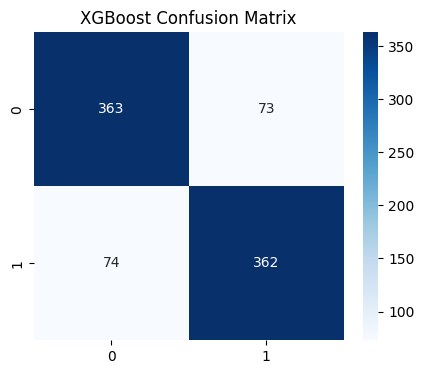

\n============================================================
Random Forest
Accuracy : 0.8131
Precision: 0.8013
Recall   : 0.8326
F1 Score : 0.8166
ROC-AUC  : 0.8922
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       436
           1       0.80      0.83      0.82       436

    accuracy                           0.81       872
   macro avg       0.81      0.81      0.81       872
weighted avg       0.81      0.81      0.81       872



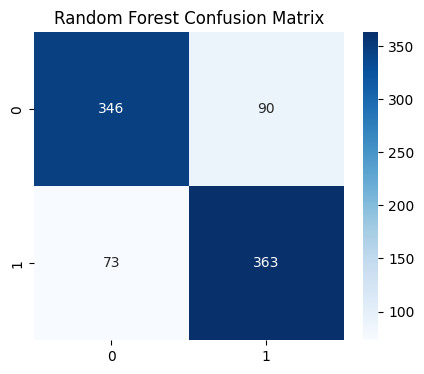

\n============================================================
SVM
Accuracy : 0.82
Precision: 0.8163
Recall   : 0.8257
F1 Score : 0.821
ROC-AUC  : 0.9025
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       436
           1       0.82      0.83      0.82       436

    accuracy                           0.82       872
   macro avg       0.82      0.82      0.82       872
weighted avg       0.82      0.82      0.82       872



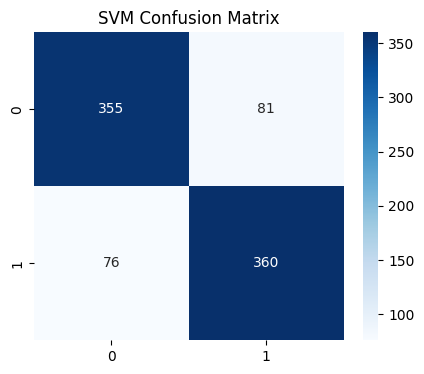

In [40]:
# =====================================================
# EVALUATION
# =====================================================

results = []

def evaluate(model, name):

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    print("\\n" + "="*60)
    print(name)
    print("="*60)

    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))
    print("ROC-AUC  :", round(auc,4))

    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(name + " Confusion Matrix")
    plt.show()

    results.append(
        [name, acc, prec, rec, f1, auc]
    )

    return auc

xgb_auc = evaluate(xgb_model, "XGBoost")
rf_auc = evaluate(rf_model, "Random Forest")
svm_auc = evaluate(svm_model, "SVM")

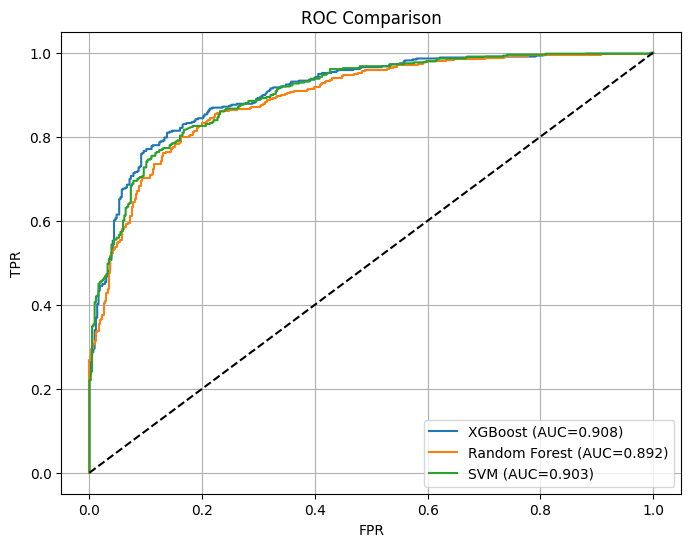

In [41]:
# =====================================================
# ROC CURVES
# =====================================================

plt.figure(figsize=(8,6))

for model, name in [
    (xgb_model, "XGBoost"),
    (rf_model, "Random Forest"),
    (svm_model, "SVM")
]:

    prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, prob)

    auc_score = roc_auc_score(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# =====================================================
# CV RESULTS
# =====================================================

print("\\n10-Fold Cross Validation")

for model, name in [
    (xgb_model, "XGBoost"),
    (rf_model, "Random Forest"),
    (svm_model, "SVM")
]:

    auc_scores = cross_val_score(
        model,
        X,
        y,
        cv=10,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"{name}: "
        f"{auc_scores.mean():.4f} ± {auc_scores.std():.4f}"
    )


\n10-Fold Cross Validation
XGBoost: 0.9016 ± 0.0168
Random Forest: 0.8860 ± 0.0191
SVM: 0.8974 ± 0.0149


\nFeature Importance
                     Feature  Importance
4                       FFMC    0.144775
12                 Lightning    0.109764
14             Season_Summer    0.106526
11                   Drought    0.102276
10                  Heatwave    0.084113
16     VegetationType_Forest    0.063265
7                        ISI    0.058328
9                        FWI    0.057846
15             Season_Winter    0.056476
17  VegetationType_Grassland    0.043683
18  VegetationType_Shrubland    0.028926
5                        DMC    0.024890
2                         Ws    0.022762
8                        BUI    0.020278
0                Temperature    0.017876
1                         RH    0.017740
6                         DC    0.017524
3                       Rain    0.012970
13             Season_Spring    0.009980


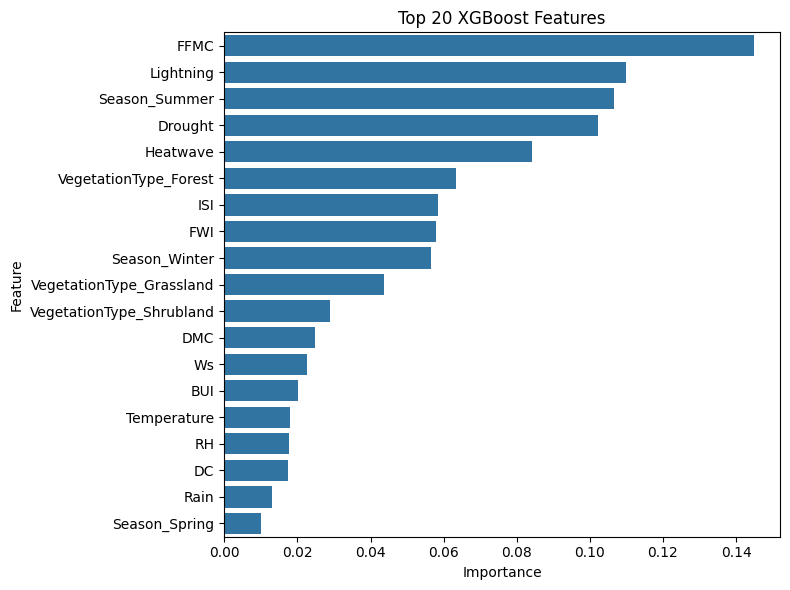

In [42]:
# =====================================================
# FEATURE IMPORTANCE
# =====================================================

best_xgb = xgb_model.named_steps["model"]

importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\\nFeature Importance")
print(importance.head(25))

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 XGBoost Features")
plt.tight_layout()
plt.show()

In [46]:
# =====================================================
# SAVE RESULTS
# =====================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("\\nDone.")


\nDone.
